# TinyML — Treinamento: ABRIR PORTA × FECHAR PORTA
### Fonte: Audacity

Este notebook usa diretamente o `dataset_audacity_mfcc.npz` da etapa anterior.

Fluxo: **NPZ → treino/validação/teste → modelo Float32 → métricas → TFLite → INT8 → comparação → artefatos para ESP32-S3**.

Como este primeiro dataset tem apenas 60 gravações de um locutor, o resultado é uma prova de conceito. Depois poderemos repetir o mesmo protocolo para o segundo locutor e para os datasets combinados.

## 1. Importações e reprodutibilidade

In [ ]:
import os, json, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Upload do `dataset_audacity_mfcc.npz`

In [ ]:
from google.colab import files
uploaded = files.upload()
nomes_npz = [n for n in uploaded if n.lower().endswith(".npz")]
if not nomes_npz:
    raise ValueError("Envie o arquivo dataset_mfcc.npz")
NPZ_PATH = Path("/content") / nomes_npz[0]
print(NPZ_PATH)

Saving dataset_audacity_mfcc.npz to dataset_audacity_mfcc.npz
/content/dataset_audacity_mfcc.npz


## 3. Carregar e validar

In [ ]:
dados = np.load(NPZ_PATH)
print("Chaves:", dados.files)

X = dados["X"].astype(np.float32)
y_texto = dados["y"].astype(str)
nomes = dados["nomes"].astype(str)

print("X:", X.shape)
print("y:", y_texto.shape)
print("nomes:", nomes.shape)

classes, qtd = np.unique(y_texto, return_counts=True)
for c, n in zip(classes, qtd):
    print(c, n)

assert len(X) == len(y_texto) == len(nomes)
assert np.isfinite(X).all()

MAPA = {"ABRIR_PORTA": 0, "FECHAR_PORTA": 1}
if set(classes) != set(MAPA):
    raise ValueError(f"Classes inesperadas: {classes}")

y = np.array([MAPA[c] for c in y_texto], dtype=np.int32)
NOMES_CLASSES = ["ABRIR_PORTA", "FECHAR_PORTA"]

Chaves: ['X', 'y', 'nomes']
X: (60, 13, 247)
y: (60,)
nomes: (60,)
ABRIR_PORTA 30
FECHAR_PORTA 30


## 4. Treino, validação e teste

Usaremos aproximadamente **70% / 15% / 15%**, com divisão estratificada. O teste fica isolado da aprendizagem.

In [ ]:
indices = np.arange(len(X))

print("Indices:", indices)

idx_treino, idx_temp = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=y
)

print("\nidx_treino:", idx_treino) # 42
print("\nidx_temp:", idx_temp)     # 18

idx_val, idx_teste = train_test_split(
    idx_temp, test_size=0.50, random_state=SEED, stratify=y[idx_temp]
)

X_treino, y_treino = X[idx_treino], y[idx_treino]
X_val, y_val = X[idx_val], y[idx_val]
X_teste, y_teste = X[idx_teste], y[idx_teste]

print("\nTreino:", X_treino.shape, np.bincount(y_treino))
print("Validação:", X_val.shape, np.bincount(y_val))
print("Teste:", X_teste.shape, np.bincount(y_teste))

print("\nArquivos de teste:")
for i in idx_teste:
    print(nomes[i], "->", y_texto[i])

Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]

idx_treino: [42  3 23 56 46 38 32 51 27  4 12 59 25  8 54 37  5 35 21 50 34 11 22 36
 52  0 53 16 43  2 40 30 47  9 15 17 31  1 13 33 24 28]

idx_temp: [45 48 10 18 39 44 55 20  6 14 49  7 41 26 58 29 19 57]

Treino: (42, 13, 247) [21 21]
Validação: (9, 13, 247) [4 5]
Teste: (9, 13, 247) [5 4]

Arquivos de teste:
ABRIR_PORTA_28.wav -> ABRIR_PORTA
FECHAR_PORTA_2.wav -> FECHAR_PORTA
FECHAR_PORTA_7.wav -> FECHAR_PORTA
ABRIR_PORTA_6.wav -> ABRIR_PORTA
FECHAR_PORTA_18.wav -> FECHAR_PORTA
ABRIR_PORTA_9.wav -> ABRIR_PORTA
ABRIR_PORTA_22.wav -> ABRIR_PORTA
ABRIR_PORTA_15.wav -> ABRIR_PORTA
FECHAR_PORTA_8.wav -> FECHAR_PORTA


## 5. Normalizar os MFCCs

A média e o desvio são calculados **somente no treino**, evitando *data leakage*. Esses valores também serão necessários no ESP32.

In [ ]:
media = np.mean(X_treino, dtype=np.float64)
desvio = np.std(X_treino, dtype=np.float64)

def normalizar(a):
    return ((a - media) / desvio).astype(np.float32)

X_treino_n = normalizar(X_treino)
X_val_n = normalizar(X_val)
X_teste_n = normalizar(X_teste)

np.savez("/content/audacity_normalizacao_mfcc.npz",
         media=np.float32(media), desvio=np.float32(desvio))

print("Média:", media)
print("Desvio:", desvio)

Média: -28.25461526863414
Desvio: 117.86187224330298


## 6. Preparar entrada da CNN

In [ ]:
X_treino_cnn = X_treino_n[..., np.newaxis] # acrescentar quarta informação, o canal -> formato esperado na CNN
X_val_cnn = X_val_n[..., np.newaxis]
X_teste_cnn = X_teste_n[..., np.newaxis]
INPUT_SHAPE = X_treino_cnn.shape[1:]
print("Input shape:", INPUT_SHAPE)

Input shape: (13, 247, 1)


## 7. Modelo Float32

Uma CNN pequena é suficiente para este primeiro experimento e mantém o foco em TinyML.

In [ ]:
tf.keras.backend.clear_session()

modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=INPUT_SHAPE),
    tf.keras.layers.Conv2D(8, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(16, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 247, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 123, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 123, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 61, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        46,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 48,129 (188.00 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Treinamento

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5
    )
]

historico = modelo.fit(
    X_treino_cnn, y_treino,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4762 - loss: 0.7282 - val_accuracy: 0.4444 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5238 - loss: 0.6964 - val_accuracy: 0.4444 - val_loss: 0.6788 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6429 - loss: 0.6602 - val_accuracy: 0.4444 - val_loss: 0.6774 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4762 - loss: 0.6590 - val_accuracy: 0.4444 - val_loss: 0.6712 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5238 - loss: 0.6253 - val_accuracy: 0.4444 - val_loss: 0.6553 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5238 - loss: 0.6144 - val_accuracy: 0.4444 - val_loss: 0.6420 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6905 - loss: 0.5762 - val_accuracy: 

## 9. Curvas de aprendizagem

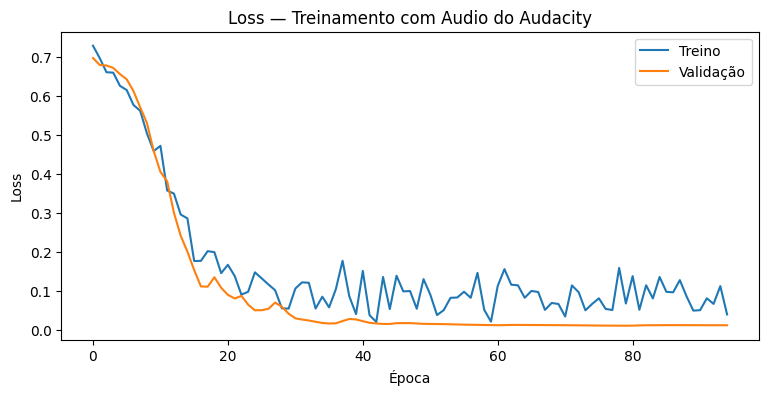

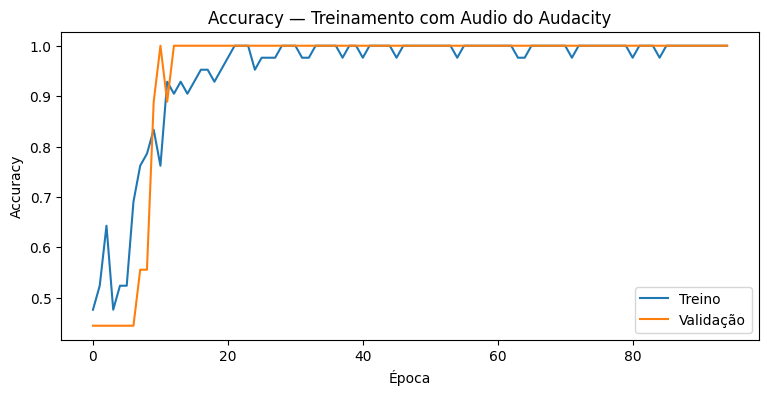

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(historico.history["loss"], label="Treino")
plt.plot(historico.history["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.title("Loss — Treinamento com Audio do Audacity")
plt.legend(); plt.show()

plt.figure(figsize=(9,4))
plt.plot(historico.history["accuracy"], label="Treino")
plt.plot(historico.history["val_accuracy"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Accuracy"); plt.title("Accuracy — Treinamento com Audio do Audacity")
plt.legend(); plt.show()

## 10. Avaliar Float32

              precision    recall  f1-score   support

 ABRIR_PORTA     1.0000    1.0000    1.0000         5
FECHAR_PORTA     1.0000    1.0000    1.0000         4

    accuracy                         1.0000         9
   macro avg     1.0000    1.0000    1.0000         9
weighted avg     1.0000    1.0000    1.0000         9



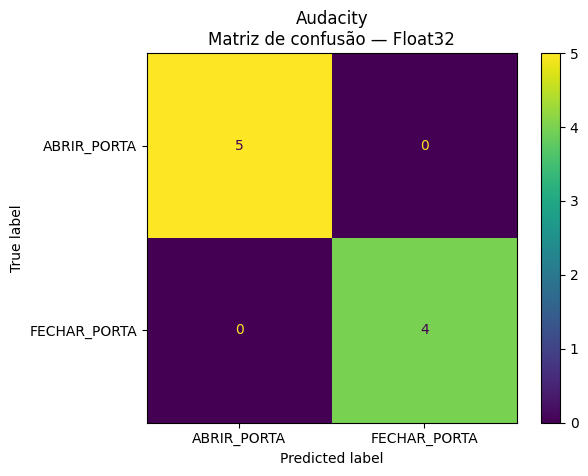

,arquivo,real,prob_FECHAR,previsto,correto
0,ABRIR_PORTA_28.wav,ABRIR_PORTA,0.000007,ABRIR_PORTA,True
1,FECHAR_PORTA_2.wav,FECHAR_PORTA,0.993710,FECHAR_PORTA,True
2,FECHAR_PORTA_7.wav,FECHAR_PORTA,0.993462,FECHAR_PORTA,True
3,ABRIR_PORTA_6.wav,ABRIR_PORTA,0.001034,ABRIR_PORTA,True
4,FECHAR_PORTA_18.wav,FECHAR_PORTA,0.981668,FECHAR_PORTA,True
5,ABRIR_PORTA_9.wav,ABRIR_PORTA,0.000006,ABRIR_PORTA,True
6,ABRIR_PORTA_22.wav,ABRIR_PORTA,0.001504,ABRIR_PORTA,True
7,ABRIR_PORTA_15.wav,ABRIR_PORTA,0.000019,ABRIR_PORTA,True
8,FECHAR_PORTA_8.wav,FECHAR_PORTA,0.993075,FECHAR_PORTA,True


In [ ]:
prob_float = modelo.predict(X_teste_cnn, verbose=0).reshape(-1)
pred_float = (prob_float >= 0.5).astype(np.int32)

print(classification_report(
    y_teste, pred_float, target_names=NOMES_CLASSES,
    digits=4, zero_division=0
))

cm = confusion_matrix(y_teste, pred_float, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=NOMES_CLASSES).plot(values_format="d")
plt.title("Audacity\nMatriz de confusão — Float32")
plt.show()

acc_float = accuracy_score(y_teste, pred_float)
p_float, r_float, f1_float, _ = precision_recall_fscore_support(
    y_teste, pred_float, average="macro", zero_division=0
)

display(pd.DataFrame({
    "arquivo": nomes[idx_teste],
    "real": [NOMES_CLASSES[i] for i in y_teste],
    "prob_FECHAR": prob_float,
    "previsto": [NOMES_CLASSES[i] for i in pred_float],
    "correto": pred_float == y_teste
}))

## 11. Converter para TFLite Float32

In [ ]:
modelo.save("/content/audacity_modelo_comandos_float32.keras")

conv = tf.lite.TFLiteConverter.from_keras_model(modelo)
tflite_float = conv.convert()
open("/content/audacity_modelo_comandos_float32.tflite","wb").write(tflite_float)

print("Float32 TFLite:", len(tflite_float), "bytes")

Saved artifact at '/tmp/tmpxuis_nzb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 247, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135009282192208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282183376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282190864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282184528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282188176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282184720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282179152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282185296: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 TFLite: 196600 bytes


## 12. Quantização INT8

O conjunto representativo usa somente exemplos do treino. Entrada e saída do modelo TFLite serão `int8`.

In [ ]:
def representative_dataset():
    for a in X_treino_cnn:
        yield [a[np.newaxis,...].astype(np.float32)]

conv8 = tf.lite.TFLiteConverter.from_keras_model(modelo)
conv8.optimizations = [tf.lite.Optimize.DEFAULT]
conv8.representative_dataset = representative_dataset
conv8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv8.inference_input_type = tf.int8
conv8.inference_output_type = tf.int8

tflite_int8 = conv8.convert()
open("/content/audacity_modelo_comandos_int8.tflite","wb").write(tflite_int8)

print("Float32:", len(tflite_float), "bytes")
print("INT8:", len(tflite_int8), "bytes")
print("Redução:", round(100*(1-len(tflite_int8)/len(tflite_float)),2), "%")

Saved artifact at '/tmp/tmpce8bj3hy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 247, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135009282192208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282183376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282190864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282184528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282188176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282184720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282179152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135009282185296: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32: 196600 bytes
INT8: 53704 bytes
Redução: 72.68 %


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 13. Avaliar INT8 no mesmo teste

Entrada: <class 'numpy.int8'> [  1  13 247   1] (0.02363765798509121, 62)
Saída: <class 'numpy.int8'> [1 1] (0.00390625, -128)
              precision    recall  f1-score   support

 ABRIR_PORTA     1.0000    1.0000    1.0000         5
FECHAR_PORTA     1.0000    1.0000    1.0000         4

    accuracy                         1.0000         9
   macro avg     1.0000    1.0000    1.0000         9
weighted avg     1.0000    1.0000    1.0000         9



/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


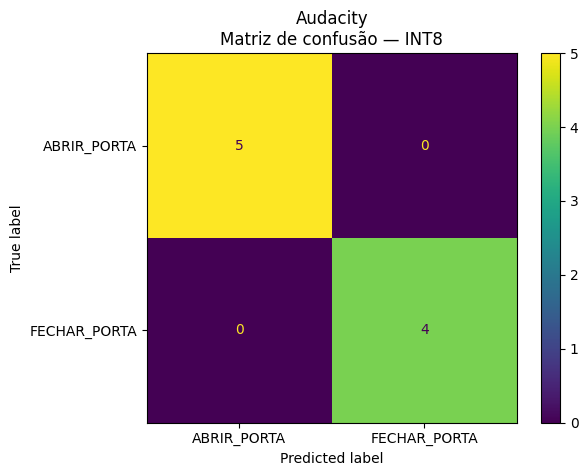

In [ ]:
interpreter = tf.lite.Interpreter(model_path="/content/audacity_modelo_comandos_int8.tflite")
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

in_scale, in_zero = inp["quantization"]
out_scale, out_zero = out["quantization"]

print("Entrada:", inp["dtype"], inp["shape"], inp["quantization"])
print("Saída:", out["dtype"], out["shape"], out["quantization"])

def qint8(a, scale, zero):
    q = np.round(a / scale + zero)
    return np.clip(q, -128, 127).astype(np.int8)

prob_int8 = []
for a in X_teste_cnn:
    entrada = qint8(a[np.newaxis,...], in_scale, in_zero)
    interpreter.set_tensor(inp["index"], entrada)
    interpreter.invoke()
    sq = interpreter.get_tensor(out["index"])
    sf = (sq.astype(np.float32) - out_zero) * out_scale
    prob_int8.append(float(sf.reshape(-1)[0]))

prob_int8 = np.array(prob_int8)
pred_int8 = (prob_int8 >= 0.5).astype(np.int32)

print(classification_report(
    y_teste, pred_int8, target_names=NOMES_CLASSES,
    digits=4, zero_division=0
))

cm8 = confusion_matrix(y_teste, pred_int8, labels=[0,1])
ConfusionMatrixDisplay(cm8, display_labels=NOMES_CLASSES).plot(values_format="d")
plt.title("Audacity\nMatriz de confusão — INT8")
plt.show()

acc_int8 = accuracy_score(y_teste, pred_int8)
p_int8, r_int8, f1_int8, _ = precision_recall_fscore_support(
    y_teste, pred_int8, average="macro", zero_division=0
)

## 14. Comparação Float32 × INT8

In [ ]:
comparacao = pd.DataFrame([
    ["Float32", acc_float, p_float, r_float, f1_float, len(tflite_float)],
    ["INT8", acc_int8, p_int8, r_int8, f1_int8, len(tflite_int8)]
], columns=["modelo","accuracy","precision_macro","recall_macro","f1_macro","bytes"])

display(comparacao.round(4))

display(pd.DataFrame({
    "arquivo": nomes[idx_teste],
    "real": [NOMES_CLASSES[i] for i in y_teste],
    "prob_float32": prob_float,
    "pred_float32": [NOMES_CLASSES[i] for i in pred_float],
    "prob_int8": prob_int8,
    "pred_int8": [NOMES_CLASSES[i] for i in pred_int8]
}))

,modelo,accuracy,precision_macro,recall_macro,f1_macro,bytes
0,Float32,1.0,1.0,1.0,1.0,196600
1,INT8,1.0,1.0,1.0,1.0,53704


,arquivo,real,prob_float32,pred_float32,prob_int8,pred_int8
0,ABRIR_PORTA_28.wav,ABRIR_PORTA,0.000007,ABRIR_PORTA,0.000000,ABRIR_PORTA
1,FECHAR_PORTA_2.wav,FECHAR_PORTA,0.993710,FECHAR_PORTA,0.992188,FECHAR_PORTA
2,FECHAR_PORTA_7.wav,FECHAR_PORTA,0.993462,FECHAR_PORTA,0.992188,FECHAR_PORTA
3,ABRIR_PORTA_6.wav,ABRIR_PORTA,0.001034,ABRIR_PORTA,0.000000,ABRIR_PORTA
4,FECHAR_PORTA_18.wav,FECHAR_PORTA,0.981668,FECHAR_PORTA,0.980469,FECHAR_PORTA
5,ABRIR_PORTA_9.wav,ABRIR_PORTA,0.000006,ABRIR_PORTA,0.000000,ABRIR_PORTA
6,ABRIR_PORTA_22.wav,ABRIR_PORTA,0.001504,ABRIR_PORTA,0.000000,ABRIR_PORTA
7,ABRIR_PORTA_15.wav,ABRIR_PORTA,0.000019,ABRIR_PORTA,0.000000,ABRIR_PORTA
8,FECHAR_PORTA_8.wav,FECHAR_PORTA,0.993075,FECHAR_PORTA,0.992188,FECHAR_PORTA


## 15. Metadados necessários para o ESP32-S3

In [ ]:
metadados = {
    "classes": NOMES_CLASSES,
    "sample_rate": 16000,
    "duracao_audio_s": 2.5,
    "n_mfcc": 13,
    "n_fft": 512,
    "win_length": 400,
    "hop_length": 160,
    "n_mels": 40,
    "mfcc_media": float(media),
    "mfcc_desvio": float(desvio),
    "input_shape": [int(v) for v in INPUT_SHAPE],
    "int8_input_scale": float(in_scale),
    "int8_input_zero_point": int(in_zero),
    "int8_output_scale": float(out_scale),
    "int8_output_zero_point": int(out_zero),
    "threshold": 0.5
}
with open("/content/audacity_metadados_modelo.json","w",encoding="utf-8") as f:
    json.dump(metadados,f,indent=2,ensure_ascii=False)

print(json.dumps(metadados,indent=2,ensure_ascii=False))

{
  "classes": [
    "ABRIR_PORTA",
    "FECHAR_PORTA"
  ],
  "sample_rate": 16000,
  "duracao_audio_s": 2.5,
  "n_mfcc": 13,
  "n_fft": 512,
  "win_length": 400,
  "hop_length": 160,
  "n_mels": 40,
  "mfcc_media": -28.25461526863414,
  "mfcc_desvio": 117.86187224330298,
  "input_shape": [
    13,
    247,
    1
  ],
  "int8_input_scale": 0.02363765798509121,
  "int8_input_zero_point": 62,
  "int8_output_scale": 0.00390625,
  "int8_output_zero_point": -128,
  "threshold": 0.5
}


## 16. Baixar todos os artefatos

In [ ]:
arquivos = [
    "/content/audacity_modelo_comandos_float32.keras",
    "/content/audacity_modelo_comandos_float32.tflite",
    "/content/audacity_modelo_comandos_int8.tflite",
    "/content/audacity_normalizacao_mfcc.npz",
    "/content/audacity_metadados_modelo.json"
]

saida = "/content/audacity_artefatos_tinyml_comandos.zip"
with zipfile.ZipFile(saida,"w",zipfile.ZIP_DEFLATED) as z:
    for a in arquivos:
        z.write(a, arcname=Path(a).name)

print("Gerado:", saida, round(os.path.getsize(saida)/1024,2), "KB")
from google.colab import files
files.download(saida)

Gerado: /content/audacity_artefatos_tinyml_comandos.zip 651.11 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# O que analisar

Primeiro valide o **Float32**. Depois compare com o **INT8**.

Observe as curvas de treino/validação, matriz de confusão, precision, recall e F1 por classe, diferença de desempenho após quantização e redução de tamanho.

Com apenas 60 áudios, uma accuracy alta ainda não demonstra generalização para outros locutores. Esse será justamente um dos próximos experimentos.